# Classification and Dimensionality Reduction on Iris Dataset

In [1]:
from sklearn import datasets
import pandas as pd

iris = datasets.load_iris()
iris_df = pd.DataFrame(data = iris.data, columns = iris.feature_names)
iris_df['species'] = iris.target_names[iris.target]

X = iris.data
y = iris.target
target_names = iris.target_names

X_memory = X.nbytes
y_memory = y.nbytes
total_memory = X_memory + y_memory

print(f"Occupied space: {total_memory} bytes")

Occupied space: 6000 bytes


### 1.2. Normalization
We normalize the data to the range [0, 1] for each column using the Min-Max scaling formula:
$$ X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}} $$


In [2]:
import numpy as np

X_normalized = np.zeros_like(X)

for col in range(X.shape[1]):
    min_val = np.min(X[:, col])
    max_val = np.max(X[:, col])
    X_normalized[:, col] = (X[:, col] - min_val) / (max_val - min_val)

X_normalized

array([[0.22222222, 0.625     , 0.06779661, 0.04166667],
       [0.16666667, 0.41666667, 0.06779661, 0.04166667],
       [0.11111111, 0.5       , 0.05084746, 0.04166667],
       [0.08333333, 0.45833333, 0.08474576, 0.04166667],
       [0.19444444, 0.66666667, 0.06779661, 0.04166667],
       [0.30555556, 0.79166667, 0.11864407, 0.125     ],
       [0.08333333, 0.58333333, 0.06779661, 0.08333333],
       [0.19444444, 0.58333333, 0.08474576, 0.04166667],
       [0.02777778, 0.375     , 0.06779661, 0.04166667],
       [0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.30555556, 0.70833333, 0.08474576, 0.04166667],
       [0.13888889, 0.58333333, 0.10169492, 0.04166667],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.        , 0.41666667, 0.01694915, 0.        ],
       [0.41666667, 0.83333333, 0.03389831, 0.04166667],
       [0.38888889, 1.        , 0.08474576, 0.125     ],
       [0.30555556, 0.79166667, 0.05084746, 0.125     ],
       [0.22222222, 0.625     ,

### 1.3. Feature Discretization
We transform one of the continuous features (e.g., the first feature) into a categorical variable ('small', 'medium', 'big') based on quartiles ($Q1$ and $Q3$).


In [3]:
feature_idx = 0
feature_name = iris.feature_names[feature_idx]
feature_data = X_normalized[:, feature_idx]

q25 = np.percentile(feature_data, 25)
q75 = np.percentile(feature_data, 75)

categorical_feature = np.empty(len(feature_data), dtype=object)
categorical_feature[feature_data < q25] = 'small'
categorical_feature[(feature_data >= q25) & (feature_data <= q75)] = 'medium'
categorical_feature[feature_data > q75] = 'big'

### 1.4. Train/Test Split
We split the dataset into random train (80%) and test (20%) subsets using numpy indices.

In [4]:
np.random.seed(42)

n_samples = X_normalized.shape[0]
indices = np.arange(n_samples)
np.random.shuffle(indices)

split_idx = int(0.8 * n_samples)
train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train = X_normalized[train_indices]
X_test = X_normalized[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 120
Test set size: 30


### 2. Support Vector Machine (SVM) Experiments

In this section, we will train different SVM models to compare their performance.

#### 2.1. Experiment 1: Base Model (RBF Kernel, Normalized Data)
We start with the base model using the Radial Basis Function (RBF) kernel on the normalized data.

Base Model Accuracy: 0.9667 (96.67%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.92      1.00      0.96        11
   virginica       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



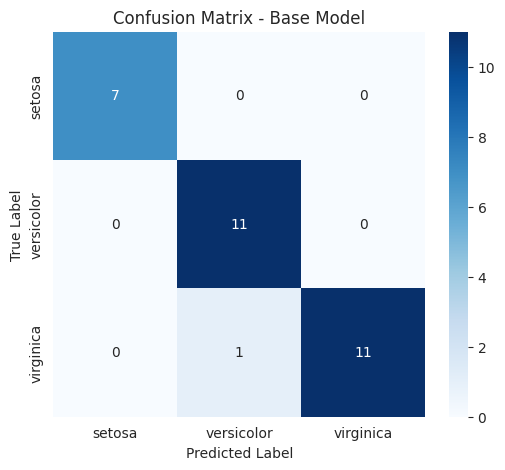

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

model_base = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
accuracy_1 = acc_base

print(f"Base Model Accuracy: {acc_base:.4f} ({acc_base*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=target_names))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Base Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

#### 2.2. Experiment 2: Unnormalized Data
Now check how the model performs without data normalization. We use the raw indices to get the original data.


Model Accuracy: 0.9667 (96.67%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.92      1.00      0.96        11
   virginica       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



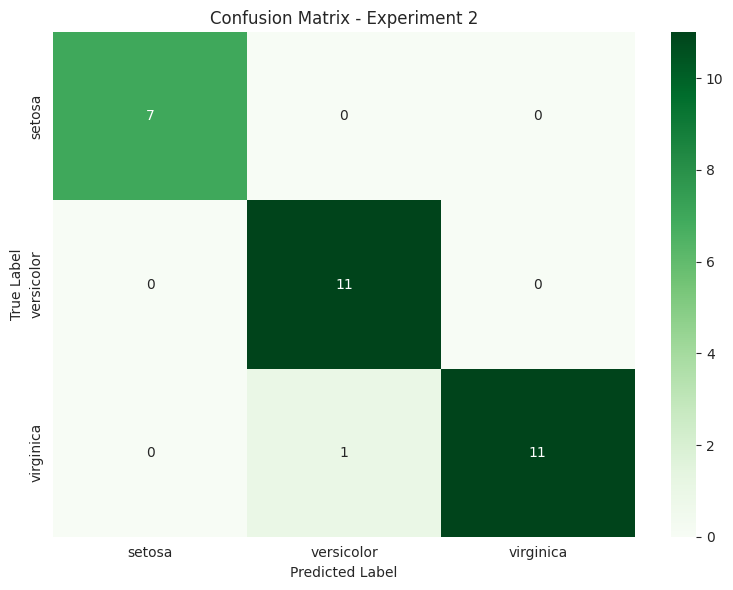

In [6]:
X_train_raw = X[train_indices]
X_test_raw = X[test_indices]
#Training
model_2 = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_2.fit(X_train_raw, y_train)

# Prediction and evaluation
y_pred_2 = model_2.predict(X_test_raw)
accuracy_2 = accuracy_score(y_test, y_pred_2)

print(f"\nModel Accuracy: {accuracy_2:.4f} ({accuracy_2*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_2, target_names=target_names))

# Confusion Matrix
cm_2 = confusion_matrix(y_test, y_pred_2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Experiment 2')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

**Comparison:** Normalized data: accuracy `accuracy_1`, Unnormalized data: `accuracy_2`.

**Conclusion:** Data normalization may improve or maintain the results depending on the specific dataset structure. In many cases with SVM, normalization is crucial because SVM is sensitive to the scale of the features.

#### 2.3. Experiment 3: SVC with Linear Kernel
Here we change the kernel from RBF to Linear to see if the data is linearly separable.


Model Accuracy: 0.9667 (96.67%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.92      1.00      0.96        11
   virginica       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



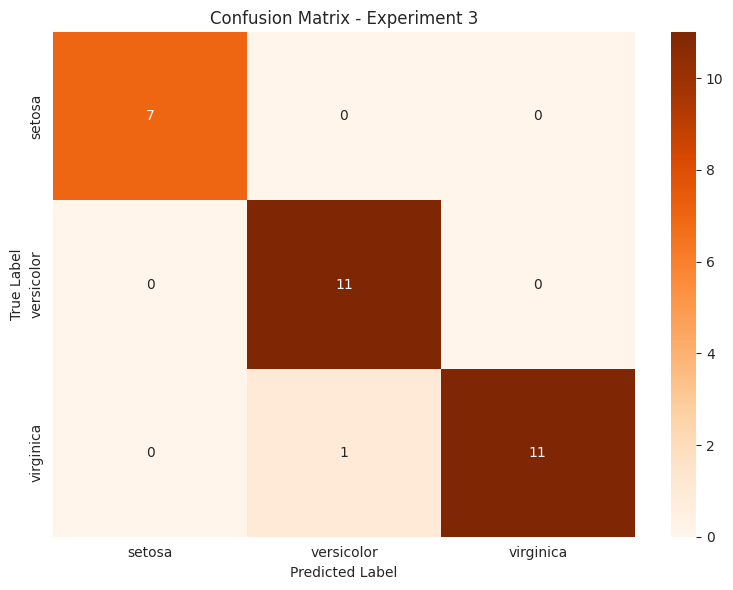

In [7]:
model_3 = SVC(kernel='linear', C=1.0, random_state=42)
model_3.fit(X_train, y_train)

y_pred_3 = model_3.predict(X_test)
accuracy_3 = accuracy_score(y_test, y_pred_3)

print(f"\nModel Accuracy: {accuracy_3:.4f} ({accuracy_3*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_3, target_names=target_names))

cm_3 = confusion_matrix(y_test, y_pred_3)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Oranges', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Experiment 3')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

**Conclusion:** The linear kernel might perform worse if the data is not linearly separable. If the accuracy is high, it suggests the classes can be separated by a straight line (or hyperplane).

#### 2.4. Experiment 4: SVC with Increased C Parameter
We increase the regularization parameter C to 10. This attempts to classify more training points correctly but might lead to overfitting.


Model Accuracy: 1.0000 (100.00%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



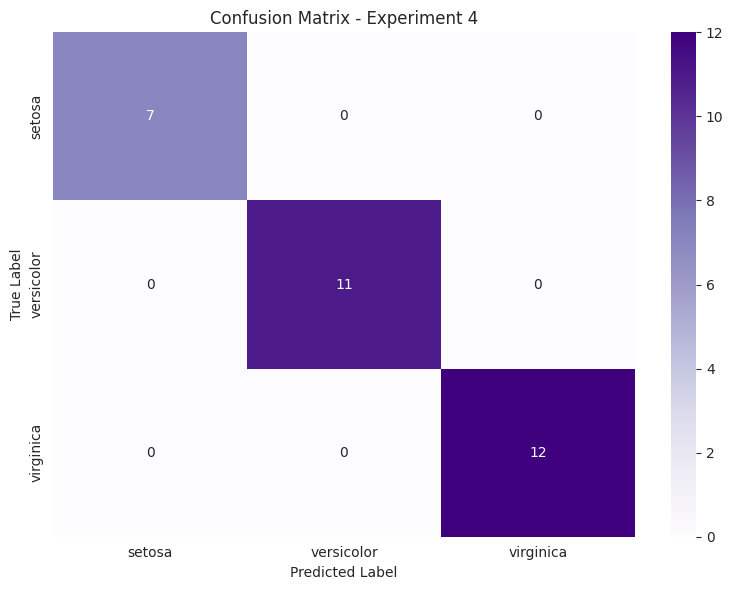

In [8]:
model_4 = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)
model_4.fit(X_train, y_train)

y_pred_4 = model_4.predict(X_test)
accuracy_4 = accuracy_score(y_test, y_pred_4)

print(f"\nModel Accuracy: {accuracy_4:.4f} ({accuracy_4*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_4, target_names=target_names))

cm_4 = confusion_matrix(y_test, y_pred_4)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_4, annot=True, fmt='d', cmap='Purples',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Experiment 4')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

**Conclusion:** Increasing the parameter C makes the model strictly penalize misclassifications, making it more sensitive to outliers.

### 2.5. Summary of Experiments
Comparing the results of all models.

Exp. 1: RBF kernel, normalized: 0.9667 (96.67%)
Exp. 2: RBF kernel, unnormalized: 0.9667 (96.67%)
Exp. 3: Linear kernel, normalized: 0.9667 (96.67%)
Exp. 4: RBF kernel (C=10), normalized: 1.0000 (100.00%)

**Best Result:** Exp. 4: RBF kernel (C=10), normalized with accuracy 1.0000


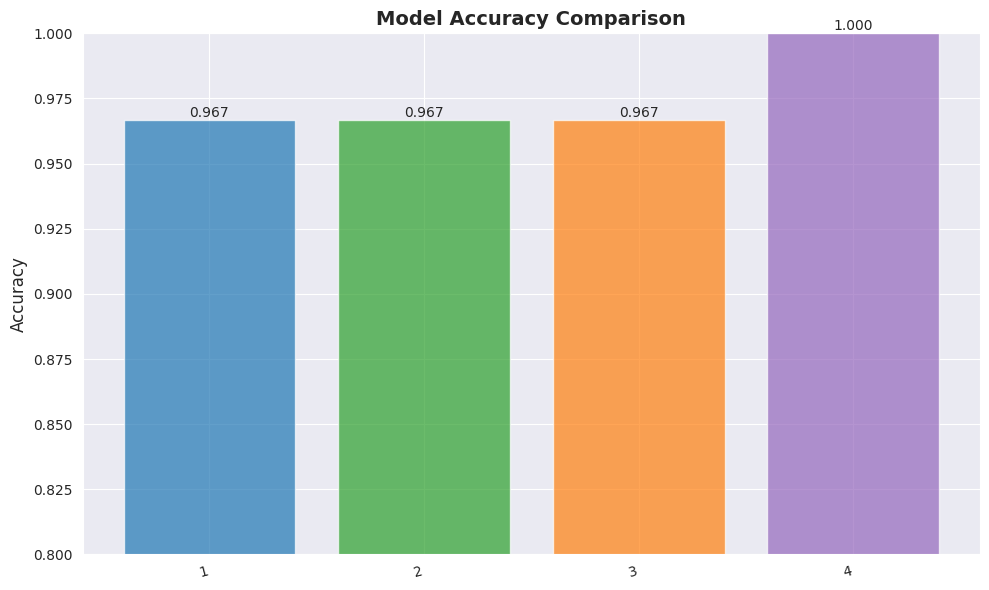

In [9]:
experiments = [
    ("Exp. 1: RBF kernel, normalized", accuracy_1),
    ("Exp. 2: RBF kernel, unnormalized", accuracy_2),
    ("Exp. 3: Linear kernel, normalized", accuracy_3),
    ("Exp. 4: RBF kernel (C=10), normalized", accuracy_4),
]

for name, acc in experiments:
    print(f"{name}: {acc:.4f} ({acc*100:.2f}%)")

best_exp = max(experiments, key=lambda x: x[1])
print(f"\n**Best Result:** {best_exp[0]} with accuracy {best_exp[1]:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
names = [e[0].replace("Exp. ", "").split(":")[0] for e in experiments]
accuracies = [e[1] for e in experiments]
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd']
bars = plt.bar(names, accuracies, color=colors, alpha=0.7)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim(0.8, 1.0)
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## Part 3: Visualization with Dimensionality Reduction

### 3.1. PCA - Principal Component Analysis

Explained variance ratio: [0.84136038 0.11751808]
Total explained variance: 0.9589


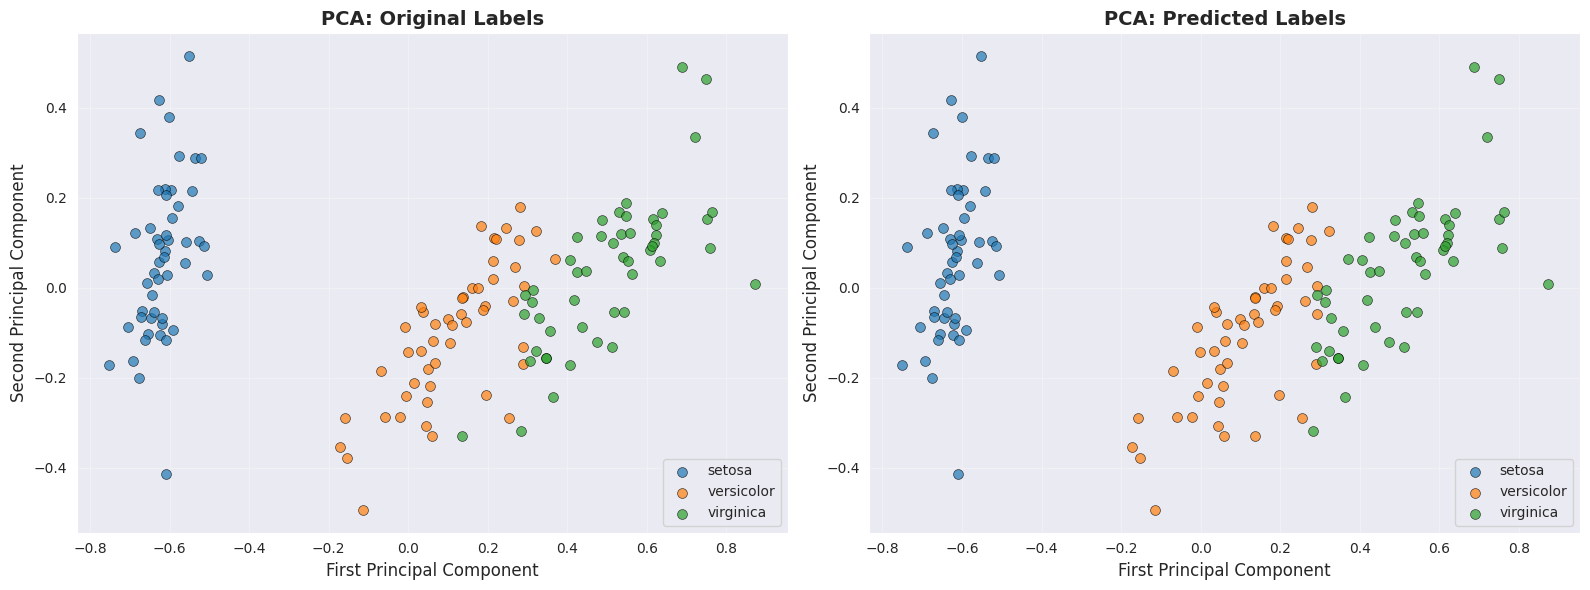

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_normalized)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {sum(pca.explained_variance_ratio_):.4f}")

y_pred_full = model_base.predict(X_normalized)

# Create subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, name in enumerate(target_names):
    mask = y == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=name, alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('First Principal Component', fontsize=12)
axes[0].set_ylabel('Second Principal Component', fontsize=12)
axes[0].set_title('PCA: Original Labels', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

for i, name in enumerate(target_names):
    mask = y_pred_full == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=name, alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('First Principal Component', fontsize=12)
axes[1].set_ylabel('Second Principal Component', fontsize=12)
axes[1].set_title('PCA: Predicted Labels', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

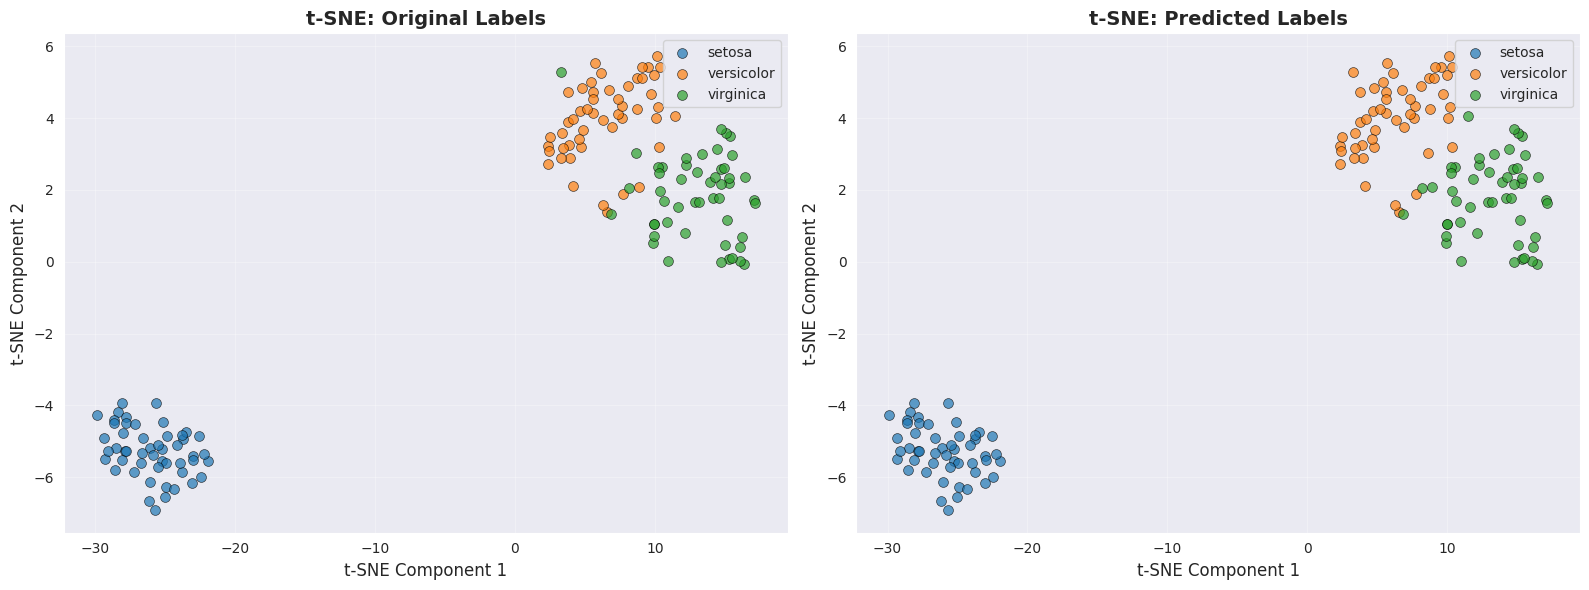

In [11]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_normalized)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Original Labels
for i, name in enumerate(target_names):
    mask = y == i
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=name, alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('t-SNE Component 1', fontsize=12)
axes[0].set_ylabel('t-SNE Component 2', fontsize=12)
axes[0].set_title('t-SNE: Original Labels', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

for i, name in enumerate(target_names):
    mask = y_pred_full == i
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],  label=name, alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('t-SNE Component 1', fontsize=12)
axes[1].set_ylabel('t-SNE Component 2', fontsize=12)
axes[1].set_title('t-SNE: Predicted Labels', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()